In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
fund_master = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/01_fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/02_nav_history_cleaned.csv"
)

aum_house = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/03_aum_by_fund_house_cleaned.csv"
)

sip_inflows = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/04_monthly_sip_inflows_cleaned.csv"
)

category_inflows = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/05_category_inflows_cleaned.csv"
)

folio_count = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/06_industry_folio_count_cleaned.csv"
)

scheme_perf = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/07_scheme_performance_cleaned.csv"
)

investor_txn = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/08_investor_transactions_cleaned.csv"
)

portfolio = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/09_portfolio_holdings_cleaned.csv"
)

benchmark = pd.read_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/data/processed/10_benchmark_indices_cleaned.csv"
)

print("All datasets loaded successfully")

All datasets loaded successfully


Historical VaR and CVaR

In [3]:
nav_history["date"] = pd.to_datetime(nav_history["date"])

nav_history = nav_history.sort_values(
    ["amfi_code", "date"]
)

nav_history["daily_return"] = (
    nav_history
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
risk_report = []

for code, group in nav_history.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) > 30:

        var95 = np.percentile(returns, 5)

        cvar95 = returns[
            returns <= var95
        ].mean()

        risk_report.append({
            "amfi_code": code,
            "VaR_95": round(var95,6),
            "CVaR_95": round(cvar95,6)
        })

var_cvar_report = pd.DataFrame(risk_report)

var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [5]:
var_cvar_report.to_csv(
    "/Users/chitranjansahu/Desktop/mutual_fund_analysis/reports/var_cvar_report.csv",
    index=False
)

Rolling 90-Day Sharpe Ratio

In [6]:
rolling_sharpe_frames = []

for code, group in nav_history.groupby("amfi_code"):

    group = group.sort_values("date")

    returns = group["daily_return"]

    group["rolling_sharpe"] = (
        returns.rolling(90).mean()
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe_frames.append(group)

rolling_sharpe = pd.concat(
    rolling_sharpe_frames
)

Plot Top 5 Funds

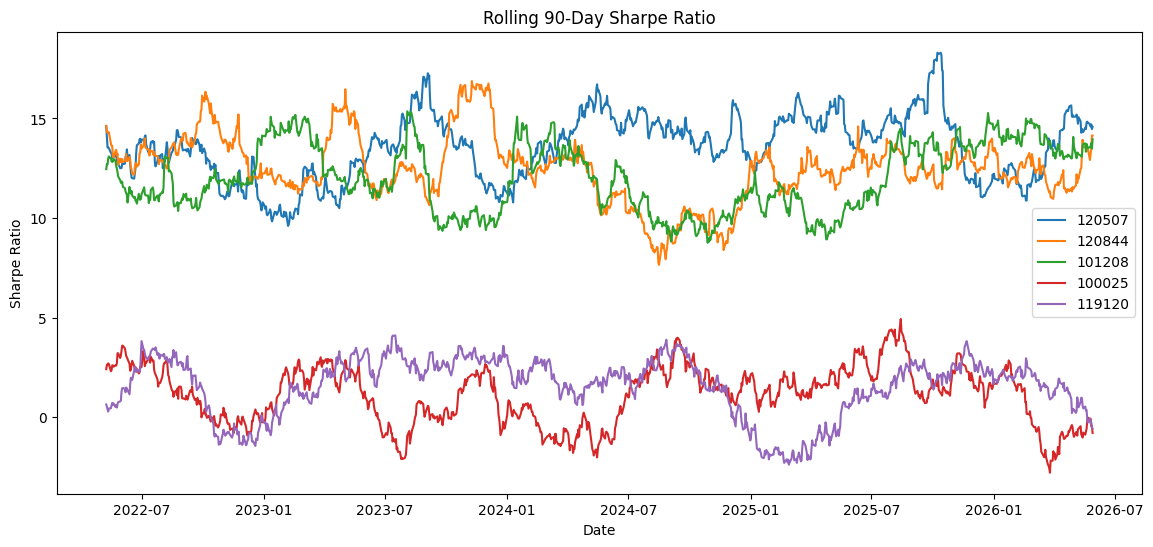

In [9]:
top5 = (
    scheme_perf
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(5)["amfi_code"]
)
plt.figure(figsize=(14,6))

for code in top5:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

Investor Cohort Analysis

In [10]:
investor_txn["transaction_date"] = pd.to_datetime(
    investor_txn["transaction_date"]
)
first_txn = (
    investor_txn
    .groupby("investor_id")
    ["transaction_date"]
    .min()
)
investor_txn["cohort_year"] = (
    investor_txn["investor_id"]
    .map(first_txn.dt.year)
)
cohort_analysis = (
    investor_txn
    .groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_analysis


,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


Top Fund Preference

In [11]:
top_fund_pref = (
    investor_txn
    .groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund_pref = (
    top_fund_pref
    .sort_values(
        ["cohort_year","count"],
        ascending=False
    )
    .drop_duplicates(
        "cohort_year"
    )
)

top_fund_pref.head()

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


Sip Continuity Analysis

In [12]:
sip_txn = investor_txn[
    investor_txn["transaction_type"]=="SIP"
].copy()
sip_txn = sip_txn.sort_values(
    ["investor_id","transaction_date"]
)

sip_txn["gap_days"] = (
    sip_txn.groupby("investor_id")
           ["transaction_date"]
           .diff()
           .dt.days
)
continuity = (
    sip_txn
    .groupby("investor_id")
    .agg(
        sip_count=("gap_days","count"),
        avg_gap=("gap_days","mean")
    )
)

continuity = continuity[
    continuity["sip_count"] >= 6
]
continuity["status"] = np.where(
    continuity["avg_gap"] > 35,
    "At Risk",
    "Active"
)

continuity.head()

,sip_count,avg_gap,status
investor_id,,,
INV000011,6,40.166667,At Risk
INV000012,7,57.000000,At Risk
INV000013,6,55.333333,At Risk
INV000014,6,75.333333,At Risk
INV000023,7,58.571429,At Risk


In [13]:
def recommend_funds(risk_level):

    result = (
        scheme_perf[
            scheme_perf["risk_grade"]
            .str.lower()
            ==
            risk_level.lower()
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    return result[
        [
            "scheme_name",
            "risk_grade",
            "sharpe_ratio"
        ]
    ]

In [14]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,DSP Midcap Fund - Regular - Growth,High,0.90


In [15]:
recommender_code = '''
import pandas as pd

funds = pd.read_csv(
"07_scheme_performance_cleaned.csv"
)

risk = input(
"Enter Risk Appetite (Low/Moderate/High): "
)

result = (
funds[
funds["risk_grade"].str.lower()
==
risk.lower()
]
.sort_values(
"sharpe_ratio",
ascending=False
)
.head(3)
)

print(result[
["scheme_name",
"risk_grade",
"sharpe_ratio"]
])
'''

with open(
    "recommender.py",
    "w"
) as f:
    f.write(recommender_code)

print("recommender.py created")

recommender.py created


Sector HHI Concentration

In [17]:
portfolio["weight_sq"] = (
    portfolio["weight_pct"] / 100
) ** 2
hhi = (
    portfolio
    .groupby("amfi_code")
    ["weight_sq"]
    .sum()
    .reset_index()
)

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


# Advanced Insights

1. Historical VaR and CVaR identify funds with the highest downside risk exposure.

2. Rolling 90-Day Sharpe ratios show which funds consistently deliver superior risk-adjusted returns.

3. Recent investor cohorts contribute the highest investment volumes and SIP participation.

4. SIP continuity analysis highlights investors with contribution gaps greater than 35 days and flags them as at-risk.

5. HHI concentration analysis reveals which equity funds maintain highly concentrated portfolios and therefore carry higher concentration risk.